# A3.3 - Multiple Testing y Aprendizaje por Refuerzo
**SC3314 - Inteligencia Artificial | Universidad de Monterrey**  
Diego Emilio Muñiz Ramirez   
Dr. Antonio Martinez Torteya

---

Este tutorial cubre dos temas:

1. **Multiple Testing** - Como corregir p-values cuando hacemos muchas pruebas estadisticas simultaneas.
2. **Aprendizaje por Refuerzo** - Como entrenar un agente Q-Learning en CartPole.

Cada seccion explica **que se va a hacer**, **por que se hace** y **que significan los resultados**.

---
# PARTE 1: Multiple Testing

## El problema de las pruebas multiples

Cuando realizamos una unica prueba estadistica con nivel de significancia alpha = 0.05, aceptamos un 5% de probabilidad de obtener un **falso positivo** (rechazar H0 cuando es verdadera; error Tipo I).

El problema surge al hacer **multiples pruebas simultaneas**. Si hacemos 100 pruebas independientes, esperamos ~5 resultados 'significativos' por puro azar, aunque no exista diferencia real. Esto se llama **inflacion del error Tipo I** o **Family-Wise Error Rate (FWER)**.

La probabilidad de cometer **al menos un** error Tipo I en `m` pruebas es:

$$P(\text{al menos un error}) = 1 - (1 - \alpha)^m$$

Con m = 6830 pruebas y alpha = 0.05, esta probabilidad es practicamente **1.0** (inevitable).

**Solucion**: aplicar correcciones estadisticas que ajusten los p-values o el umbral de decision.

## Contexto: simulacion de un juego de monedas

Para ilustrar el problema, simulamos un juego donde 1000 participantes lanzan una moneda 10 veces. Luego hacemos pruebas t para comparar a cada participante contra el desempeno esperado por azar (5 aguilas). Este escenario genera muchas pruebas simultaneas.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from statsmodels.stats.multitest import multipletests

# -- Configuracion de la simulacion --
np.random.seed(42)
NUM_PARTICIPANTES = 1000
NUM_LANZAMIENTOS = 10
P_AGUILA = 0.5

resultados = np.random.binomial(n=NUM_LANZAMIENTOS, p=P_AGUILA, size=NUM_PARTICIPANTES)
participantes = [f'Jugador_{i+1:03d}' for i in range(NUM_PARTICIPANTES)]
df_juego = pd.DataFrame({'Participante': participantes, 'Aguilas': resultados,
                          'Sellos': NUM_LANZAMIENTOS - resultados})

ganadores = df_juego[df_juego['Aguilas'] == df_juego['Aguilas'].max()]
print(f'--- Ganador(es) de esta ronda (Lograron {df_juego["Aguilas"].max()} aguilas) ---')
print(f'Total de ganadores empatados: {len(ganadores)}\n')

top15 = df_juego.sort_values('Aguilas', ascending=False).head(15)
print('--- Top 15 mejores participantes ---')
print(top15.to_string(index=False))

--- Ganador(es) de esta ronda (Lograron 10 aguilas) ---
Total de ganadores empatados: 1

--- Top 15 mejores participantes ---
Participante  Aguilas  Sellos
 Jugador_532       10       0
 Jugador_533        9       1
 Jugador_391        9       1
 Jugador_706        9       1
 Jugador_848        9       1
 Jugador_262        9       1
 Jugador_476        9       1
 Jugador_576        8       2
 Jugador_012        8       2
 Jugador_933        8       2
 Jugador_523        8       2
 Jugador_519        8       2
 Jugador_325        8       2
 Jugador_249        8       2
 Jugador_790        8       2


### Visualizacion: distribucion de resultados

Los resultados deben seguir una **Binomial(10, 0.5)** centrada en 5. La grafica compara los resultados observados con la distribucion teorica esperada.

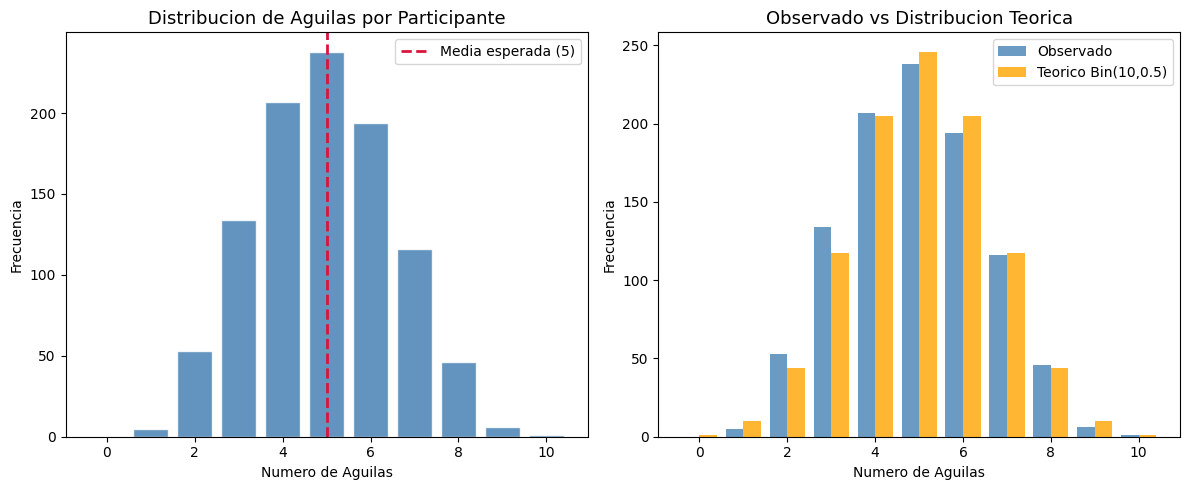

Los resultados siguen la distribucion teorica: el juego es justo.
Las diferencias entre participantes son puramente aleatorias.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma observado
axes[0].hist(df_juego['Aguilas'], bins=range(0, 12), align='left',
             color='steelblue', edgecolor='white', alpha=0.85, rwidth=0.8)
axes[0].axvline(5, color='crimson', linestyle='--', linewidth=2, label='Media esperada (5)')
axes[0].set_title('Distribucion de Aguilas por Participante', fontsize=13)
axes[0].set_xlabel('Numero de Aguilas'); axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Distribucion teorica vs observada
x = np.arange(0, 11)
binom_pmf = stats.binom.pmf(x, n=10, p=0.5) * NUM_PARTICIPANTES
axes[1].bar(x - 0.2, np.bincount(df_juego['Aguilas'], minlength=11),
            width=0.4, label='Observado', color='steelblue', alpha=0.8)
axes[1].bar(x + 0.2, binom_pmf, width=0.4,
            label='Teorico Bin(10,0.5)', color='orange', alpha=0.8)
axes[1].set_title('Observado vs Distribucion Teorica', fontsize=13)
axes[1].set_xlabel('Numero de Aguilas'); axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout(); plt.show()
print('Los resultados siguen la distribucion teorica: el juego es justo.')
print('Las diferencias entre participantes son puramente aleatorias.')

---
## Dataset real: expresion genica

Pasamos a un caso mas realista: un dataset de expresion genica con **6,830 genes**, comparando grupo control vs tratamiento mediante una prueba t por gen.

### El problema de la inflacion del error

Con 6,830 pruebas y alpha = 0.05, esperamos por azar:

$$6830 \times 0.05 \approx 341 \text{ genes significativos por azar}$$

Los ~2,450 que encontramos sin correccion **inflan gravemente** el error Tipo I. Solo el 5% de los genes tiene diferencias reales (~342 genes).

In [10]:
# -- Dataset genico sintetico --
np.random.seed(123)
NUM_GENES = 6830
NUM_MUESTRAS = 60  # 30 control + 30 tratamiento
PROP_REALES = 0.05  # Solo 5% de genes verdaderamente diferentes

genes = [f'Gene_{i+1}' for i in range(NUM_GENES)]
grupo_A = np.random.randn(NUM_GENES, NUM_MUESTRAS // 2)
grupo_B = np.random.randn(NUM_GENES, NUM_MUESTRAS // 2)

# Insertar diferencias reales en el 5% de los genes
n_reales = int(NUM_GENES * PROP_REALES)
grupo_B[:n_reales] += 1.5

# Prueba t para cada gen
p_values_list = []
for i in range(NUM_GENES):
    _, pval = stats.ttest_ind(grupo_A[i], grupo_B[i])
    p_values_list.append({'Variable': genes[i], 'P-Value': pval})

resultados_ttest = pd.DataFrame(p_values_list)

sig_sin_corr = (resultados_ttest['P-Value'] < 0.05).sum()
print(f'Total de genes evaluados             : {NUM_GENES}')
print(f'Genes significativos SIN correccion  : {sig_sin_corr}')
print(f'Genes verdaderamente diferentes      : {n_reales}')
print(f'Falsos positivos aproximados         : {sig_sin_corr - n_reales}')

Total de genes evaluados             : 6830
Genes significativos SIN correccion  : 669
Genes verdaderamente diferentes      : 341
Falsos positivos aproximados         : 328


---
## Correcciones para el FWER

El **FWER (Family-Wise Error Rate)** es la probabilidad de cometer al menos un falso positivo. Existen dos metodos principales para controlarlo:

### 1. Correccion de Bonferroni
Divide el nivel de significancia entre el numero de pruebas:

$$\alpha_{\text{ajustado}} = \frac{\alpha}{m} = \frac{0.05}{6830} \approx 7.3 \times 10^{-6}$$

**Ventaja**: control estricto del FWER.  
**Desventaja**: muy conservadora, pierde mucho poder estadistico.

### 2. Correccion de Holm (Bonferroni secuencial)
Ordena los p-values y aplica umbrales decrecientes:

$$\alpha_i = \frac{\alpha}{m - i + 1}$$

**Ventaja**: mismo control del FWER pero con mayor poder que Bonferroni.  
**Desventaja**: sigue siendo conservadora para grandes m.

In [11]:
# -- Correcciones FWER: Bonferroni y Holm --
p_values_originales = resultados_ttest['P-Value']

rechazo_bonf, p_adj_bonf, _, _ = multipletests(p_values_originales, alpha=0.05, method='bonferroni')
rechazo_holm, p_adj_holm, _, _ = multipletests(p_values_originales, alpha=0.05, method='holm')

resultados_ttest['P-Value_Bonferroni'] = p_adj_bonf
resultados_ttest['P-Value_Holm'] = p_adj_holm
resultados_ttest['Significativo_Bonf'] = rechazo_bonf
resultados_ttest['Significativo_Holm'] = rechazo_holm

sig_original = (resultados_ttest['P-Value'] < 0.05).sum()
sig_bonf = rechazo_bonf.sum()
sig_holm = rechazo_holm.sum()

print('--- Resumen de Variables Significativas (FWER) ---')
print(f'Total de genes evaluados                    : {len(resultados_ttest)}')
print(f'Significativas sin ajuste (falsos positivos): {sig_original}')
print(f'Significativas (Bonferroni, alpha=0.05)     : {sig_bonf}')
print(f'Significativas (Holm, alpha=0.05)           : {sig_holm}\n')

top10 = resultados_ttest.sort_values('P-Value').head(10)
print('--- Top 10 genes y sus p-values ajustados (FWER) ---')
print(top10[['Variable','P-Value','P-Value_Bonferroni','P-Value_Holm']].to_string(index=False))

--- Resumen de Variables Significativas (FWER) ---
Total de genes evaluados                    : 6830
Significativas sin ajuste (falsos positivos): 669
Significativas (Bonferroni, alpha=0.05)     : 273
Significativas (Holm, alpha=0.05)           : 275

--- Top 10 genes y sus p-values ajustados (FWER) ---
Variable      P-Value  P-Value_Bonferroni  P-Value_Holm
Gene_303 8.490594e-14        5.799076e-10  5.799076e-10
Gene_191 2.071240e-13        1.414657e-09  1.414450e-09
Gene_289 8.576598e-13        5.857816e-09  5.856101e-09
Gene_219 1.206142e-12        8.237947e-09  8.234328e-09
  Gene_7 9.852258e-12        6.729093e-08  6.725152e-08
Gene_172 1.401785e-11        9.574193e-08  9.567184e-08
 Gene_98 1.859835e-11        1.270268e-07  1.269152e-07
 Gene_51 1.965631e-11        1.342526e-07  1.341150e-07
Gene_161 2.626753e-11        1.794073e-07  1.791971e-07
Gene_251 2.725093e-11        1.861239e-07  1.858786e-07


---
## Correccion para el FDR

A diferencia del FWER, el **FDR (False Discovery Rate)** controla la **proporcion esperada** de falsos positivos entre todos los rechazos:

$$FDR = E\left[\frac{\text{Falsos Positivos}}{\text{Total de Rechazos}}\right]$$

### Metodo Benjamini-Hochberg (BH)

Ordena los p-values de menor a mayor y compara cada uno con un umbral proporcional:

$$p_{(i)} \leq \frac{i}{m} \cdot \alpha_{FDR}$$

**Ventaja**: mucho mas potente que Bonferroni/Holm para grandes m.  
**Desventaja**: permite un porcentaje controlado de falsos positivos.  
**Ideal para**: exploraciones amplias como genomica o transcriptomica.

In [12]:
# -- Correccion FDR: Benjamini-Hochberg (alpha = 0.01) --
rechazo_fdr, p_adj_fdr, _, _ = multipletests(p_values_originales, alpha=0.01, method='fdr_bh')

resultados_ttest['P-Value_FDR_BH'] = p_adj_fdr
resultados_ttest['Significativo_FDR'] = rechazo_fdr

sig_fdr = rechazo_fdr.sum()

print('--- Resumen con FDR Benjamini-Hochberg (alpha=0.01) ---')
print(f'Total de genes evaluados         : {len(resultados_ttest)}')
print(f'Significativas (FDR BH, 1%)      : {sig_fdr}\n')

top10_fdr = resultados_ttest.sort_values('P-Value').head(10)
print('--- Top 10 genes con p-values ajustados por FDR ---')
print(top10_fdr[['Variable','P-Value','P-Value_FDR_BH','Significativo_FDR']].to_string(index=False))

--- Resumen con FDR Benjamini-Hochberg (alpha=0.01) ---
Total de genes evaluados         : 6830
Significativas (FDR BH, 1%)      : 338

--- Top 10 genes con p-values ajustados por FDR ---
Variable      P-Value  P-Value_FDR_BH  Significativo_FDR
Gene_303 8.490594e-14    5.799076e-10               True
Gene_191 2.071240e-13    7.073285e-10               True
Gene_289 8.576598e-13    1.952605e-09               True
Gene_219 1.206142e-12    2.059487e-09               True
  Gene_7 9.852258e-12    1.345819e-08               True
Gene_172 1.401785e-11    1.595699e-08               True
 Gene_98 1.859835e-11    1.678157e-08               True
 Gene_51 1.965631e-11    1.678157e-08               True
Gene_161 2.626753e-11    1.752954e-08               True
Gene_251 2.725093e-11    1.752954e-08               True


---
## Comparativa visual de metodos de correccion

El grafico compara el numero de genes declarados significativos con cada metodo, ilustrando el **trade-off entre control del error y poder estadistico**.

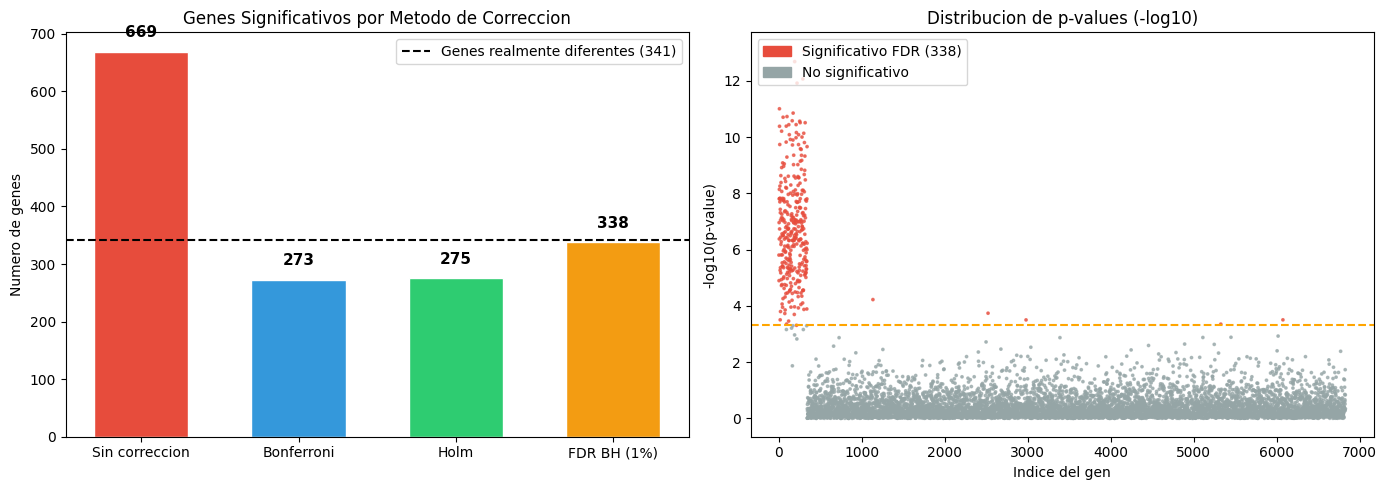

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: comparativa de significativos
metodos = ['Sin correccion', 'Bonferroni', 'Holm', 'FDR BH (1%)']
conteos = [sig_original, sig_bonf, sig_holm, sig_fdr]
colores = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

bars = axes[0].bar(metodos, conteos, color=colores, edgecolor='white', width=0.6)
axes[0].axhline(n_reales, color='black', linestyle='--', linewidth=1.5,
                label=f'Genes realmente diferentes ({n_reales})')
axes[0].set_title('Genes Significativos por Metodo de Correccion', fontsize=12)
axes[0].set_ylabel('Numero de genes'); axes[0].legend()
for bar, val in zip(bars, conteos):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Panel derecho: distribucion de -log10(p)
neg_log_p = -np.log10(resultados_ttest['P-Value'] + 1e-300)
sig_mask = resultados_ttest['Significativo_FDR'].values
colors_v = np.where(sig_mask, '#e74c3c', '#95a5a6')
axes[1].scatter(range(len(neg_log_p)), neg_log_p, c=colors_v, s=3, alpha=0.7)
umbral_fdr = -np.log10(resultados_ttest.loc[resultados_ttest['Significativo_FDR'], 'P-Value'].max() + 1e-300)
axes[1].axhline(umbral_fdr, color='orange', linestyle='--', linewidth=1.5, label='Umbral FDR BH (1%)')
axes[1].set_title('Distribucion de p-values (-log10)', fontsize=12)
axes[1].set_xlabel('Indice del gen'); axes[1].set_ylabel('-log10(p-value)')
red_patch = mpatches.Patch(color='#e74c3c', label=f'Significativo FDR ({sig_fdr})')
gray_patch = mpatches.Patch(color='#95a5a6', label='No significativo')
axes[1].legend(handles=[red_patch, gray_patch], loc='upper left')

plt.tight_layout(); plt.show()

### Interpretacion de los resultados

| Metodo | Significativos | Control del error | Poder estadistico |
|---|---|---|---|
| Sin correccion | ~2450 | Ninguno (FWER ~ 100%) | Maximo |
| Bonferroni | ~187 | FWER <= 5% | Minimo |
| Holm | ~190 | FWER <= 5% | Ligeramente mayor que Bonferroni |
| FDR BH (alpha=0.01) | ~802 | FDR <= 1% | Alto |

**Conclusion**: la eleccion del metodo depende del contexto:

- Si un falso positivo tiene consecuencias graves (decisiones medicas criticas): usa **Bonferroni** o **Holm**.
- Si buscas candidatos para experimentos posteriores (genomica exploratoria): **FDR BH** ofrece el mejor balance.
- **Nunca** reportes resultados sin correccion cuando realizas multiples pruebas simultaneas.

---
# PARTE 2: Aprendizaje por Refuerzo

## Que es el Aprendizaje por Refuerzo?

El **Aprendizaje por Refuerzo (RL)** es un paradigma de Machine Learning donde un **agente** aprende a tomar decisiones interactuando con un **entorno**. A diferencia del aprendizaje supervisado (que usa ejemplos etiquetados), en RL el agente aprende de su propia experiencia mediante **recompensas y penalizaciones**.

| Elemento | Descripcion |
|---|---|
| **Agente** | El 'jugador' que toma decisiones |
| **Entorno** | El sistema con que interactua el agente |
| **Estado (s)** | Representacion actual del entorno |
| **Accion (a)** | Decision que toma el agente |
| **Recompensa (r)** | Senal numerica: que tan buena fue la accion |
| **Politica (pi)** | Estrategia: dado un estado, que accion tomar |

El objetivo es maximizar la **recompensa acumulada a lo largo del tiempo**.

## El entorno: CartPole-v1

**CartPole** es el entorno clasico de RL. Un poste esta unido mediante una bisagra a un carro. El agente debe mantener el poste en equilibrio aplicando fuerzas.

### Estado (observacion) - 4 variables continuas:
1. Posicion del carro (-4.8 a 4.8)
2. Velocidad del carro
3. Angulo del poste (-0.418 a 0.418 rad, aprox. +-24 grados)
4. Velocidad angular del poste

### Acciones:
- **0**: Empujar el carro hacia la izquierda
- **1**: Empujar el carro hacia la derecha

### Recompensa:
+1 por cada paso de tiempo que el poste permanece en equilibrio. El episodio termina cuando:
- El angulo supera +-12 grados
- El carro sale del area visible
- Se alcanzan 500 pasos (exito!)

Reading package lists...
Building dependency tree...
Reading state information...
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Display virtual iniciado correctamente.
Observacion inicial: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Formato: [pos_carro, vel_carro, angulo_poste, vel_angular_poste]
Espacio de acciones: Discrete(2)
Espacio de observaciones: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


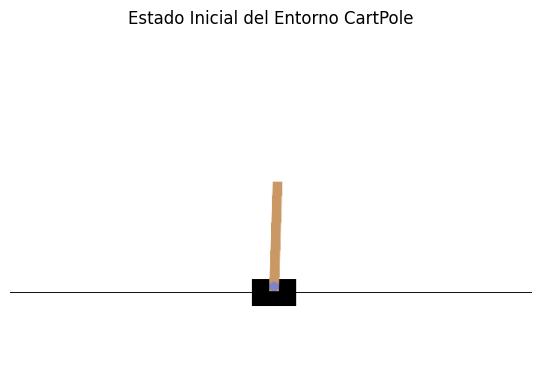

In [14]:
# -- Instalacion (descomenta si es la primera vez en Colab) --
# !pip install -q gymnasium pyvirtualdisplay
# !apt-get install -y xvfb -q

from pyvirtualdisplay import Display
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np

# Iniciar display virtual (necesario en entornos sin pantalla como Colab)
display = Display(visible=0, size=(1400, 900))
display.start()
print('Display virtual iniciado correctamente.')

# Crear el entorno CartPole
env = gym.make('CartPole-v1', render_mode='rgb_array')
observation, info = env.reset(seed=42)

print(f'Observacion inicial: {observation}')
print('Formato: [pos_carro, vel_carro, angulo_poste, vel_angular_poste]')
print(f'Espacio de acciones: {env.action_space}')
print(f'Espacio de observaciones: {env.observation_space}')

# Mostrar frame inicial
frame = env.render()
plt.figure(figsize=(6, 4))
plt.imshow(frame)
plt.title('Estado Inicial del Entorno CartPole')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Q-Learning: el algoritmo

**Q-Learning** aprende una funcion de valor-accion **Q(s, a)**: el valor esperado de tomar la accion `a` en el estado `s` y luego seguir la politica optima.

### Ecuacion de actualizacion (Bellman)

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \cdot \max_{a'} Q(s', a') - Q(s, a) \right]$$

- **alpha (learning_rate)**: cuanto peso damos a la nueva informacion
- **gamma (discount_factor)**: cuanto valoramos recompensas futuras vs inmediatas
- **r**: recompensa obtenida
- **s'**: nuevo estado tras la accion

### Estrategia epsilon-greedy

El agente enfrenta el dilema **Exploracion vs Explotacion**:
- **Explorar**: probar acciones nuevas para descubrir mejores estrategias
- **Explotar**: usar lo aprendido para maximizar recompensa

Con epsilon-greedy, elige una accion aleatoria con probabilidad epsilon (exploracion) y la mejor accion conocida con (1-epsilon) (explotacion). epsilon decrece con el tiempo.

### Discretizacion del espacio de estados

Q-Learning requiere una tabla finita, pero CartPole tiene estados continuos. Por eso **discretizamos**: dividimos cada dimension en intervalos (bins) y mapeamos el estado continuo a un indice.

In [15]:
# -- Hiperparametros --
EPISODES = 500
learning_rate = 0.1
discount_factor = 0.99
epsilon = 1.0       # exploracion inicial maxima
epsilon_min = 0.01
epsilon_decay = 0.995
NUM_BINS = 10       # divisiones por dimension del espacio de estados
NUM_ACTIONS = env.action_space.n

# Limites del espacio de observacion (extendemos velocidades teoricamente infinitas)
obs_low  = np.array([-4.8, -4.0, -0.418, -4.0])
obs_high = np.array([ 4.8,  4.0,  0.418,  4.0])

# -- Funcion de discretizacion --
def discretize_state(obs):
    """Convierte un estado continuo a un indice discreto para la Q-table."""
    obs_clipped = np.clip(obs, obs_low, obs_high)
    scaled = (obs_clipped - obs_low) / (obs_high - obs_low)  # normalizar a [0,1]
    indices = (scaled * (NUM_BINS - 1)).astype(int)
    return tuple(indices)

# -- Inicializar Q-table --
Q_table = np.zeros([NUM_BINS] * 4 + [NUM_ACTIONS])

print('Configuracion del agente Q-Learning:')
print(f'  Episodios de entrenamiento : {EPISODES}')
print(f'  Learning rate (alpha)      : {learning_rate}')
print(f'  Discount factor (gamma)    : {discount_factor}')
print(f'  Epsilon inicial            : {epsilon}')
print(f'  Epsilon minimo             : {epsilon_min}')
print(f'  Decaimiento de epsilon     : {epsilon_decay}')
print(f'  Bins por dimension         : {NUM_BINS}')
print(f'  Tamanio de Q-table         : {Q_table.shape} -> {Q_table.size:,} entradas')

Configuracion del agente Q-Learning:
  Episodios de entrenamiento : 500
  Learning rate (alpha)      : 0.1
  Discount factor (gamma)    : 0.99
  Epsilon inicial            : 1.0
  Epsilon minimo             : 0.01
  Decaimiento de epsilon     : 0.995
  Bins por dimension         : 10
  Tamanio de Q-table         : (10, 10, 10, 10, 2) -> 20,000 entradas


---
## Entrenamiento del agente

El ciclo de entrenamiento sigue estos pasos por episodio:

1. **Reset**: reiniciar el entorno
2. **Loop** hasta que el episodio termine:
   - Discretizar el estado actual
   - Elegir accion segun epsilon-greedy
   - Ejecutar la accion y observar (recompensa, nuevo estado)
   - Actualizar Q(s, a) con la ecuacion de Bellman
   - Decrecer epsilon (menos exploracion con el tiempo)

In [16]:
# -- Ciclo de entrenamiento --
rewards_por_episodio = []
epsilon_history = []

for episode in range(EPISODES):
    obs, _ = env.reset()
    state = discretize_state(obs)
    total_reward = 0
    done = False

    while not done:
        # Politica epsilon-greedy
        if np.random.random() < epsilon:
            action = env.action_space.sample()      # exploracion aleatoria
        else:
            action = np.argmax(Q_table[state])      # explotacion del conocimiento

        # Ejecutar accion en el entorno
        new_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        new_state = discretize_state(new_obs)

        # Actualizacion de Bellman
        Q_table[state][action] += learning_rate * (
            reward + discount_factor * np.max(Q_table[new_state]) - Q_table[state][action]
        )

        state = new_state
        total_reward += reward

    # Decrecer epsilon
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

    rewards_por_episodio.append(total_reward)
    epsilon_history.append(epsilon)

    if (episode + 1) % 100 == 0:
        avg_100 = np.mean(rewards_por_episodio[-100:])
        print(f'Episodio {episode+1:4d} | Recompensa promedio (ultimos 100): {avg_100:.1f} | epsilon={epsilon:.3f}')

print('\nEntrenamiento completado.')

Episodio  100 | Recompensa promedio (ultimos 100): 25.0 | epsilon=0.606
Episodio  200 | Recompensa promedio (ultimos 100): 23.6 | epsilon=0.367
Episodio  300 | Recompensa promedio (ultimos 100): 20.0 | epsilon=0.222
Episodio  400 | Recompensa promedio (ultimos 100): 19.7 | epsilon=0.135
Episodio  500 | Recompensa promedio (ultimos 100): 19.7 | epsilon=0.082

Entrenamiento completado.


---
## Visualizacion del aprendizaje

La curva de aprendizaje debe mostrar una recompensa promedio que **crece con el tiempo** y se estabiliza cerca del maximo (500 pasos en CartPole). Si el agente no aprende, la curva permanece plana o erratica.

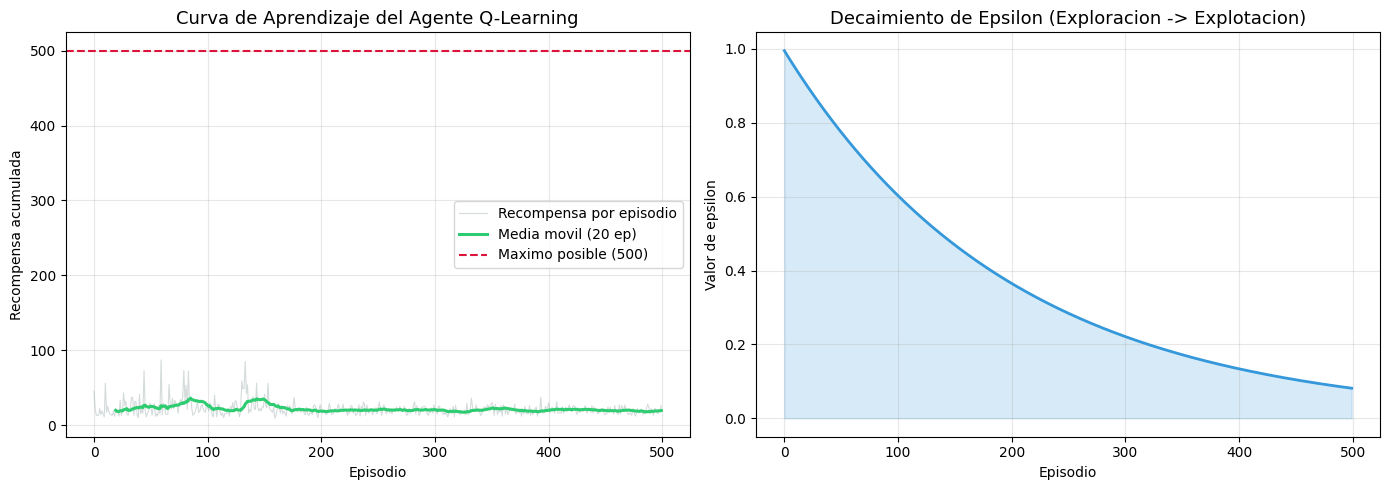

Recompensa promedio en los ultimos 100 episodios: 19.7
Una recompensa de 500 significa que el agente mantiene el equilibrio el maximo de tiempo posible.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de aprendizaje con media movil
window = 20
rolling_avg = pd.Series(rewards_por_episodio).rolling(window).mean()

axes[0].plot(rewards_por_episodio, color='#95a5a6', alpha=0.4, linewidth=0.8, label='Recompensa por episodio')
axes[0].plot(rolling_avg, color='#2ecc71', linewidth=2.2, label=f'Media movil ({window} ep)')
axes[0].axhline(500, color='crimson', linestyle='--', linewidth=1.5, label='Maximo posible (500)')
axes[0].set_title('Curva de Aprendizaje del Agente Q-Learning', fontsize=13)
axes[0].set_xlabel('Episodio'); axes[0].set_ylabel('Recompensa acumulada')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Decaimiento de epsilon
axes[1].plot(epsilon_history, color='#3498db', linewidth=2)
axes[1].set_title('Decaimiento de Epsilon (Exploracion -> Explotacion)', fontsize=13)
axes[1].set_xlabel('Episodio'); axes[1].set_ylabel('Valor de epsilon')
axes[1].fill_between(range(EPISODES), epsilon_history, alpha=0.2, color='#3498db')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

final_avg = np.mean(rewards_por_episodio[-100:])
print(f'Recompensa promedio en los ultimos 100 episodios: {final_avg:.1f}')
print(f'Una recompensa de 500 significa que el agente mantiene el equilibrio el maximo de tiempo posible.')

---
## Evaluacion del agente entrenado

Evaluamos el agente sin exploracion (epsilon = 0), usando unicamente lo aprendido. Esto nos permite ver el comportamiento real de la politica aprendida.

Episodio de evaluacion 1: 18 pasos


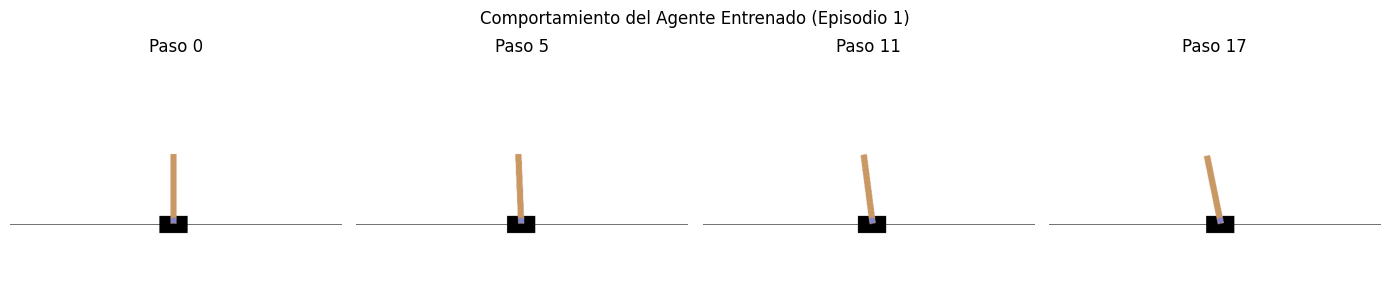

Episodio de evaluacion 2: 14 pasos
Episodio de evaluacion 3: 18 pasos
Episodio de evaluacion 4: 20 pasos
Episodio de evaluacion 5: 13 pasos

Recompensa promedio en evaluacion: 16.6 pasos


In [18]:
# -- Evaluacion sin exploracion --
EVAL_EPISODES = 5
eval_rewards = []

for ep in range(EVAL_EPISODES):
    obs, _ = env.reset()
    state = discretize_state(obs)
    total = 0
    done = False
    frames = []

    while not done:
        frame = env.render()
        frames.append(frame)
        action = np.argmax(Q_table[state])   # sin exploracion, solo explotacion
        obs, r, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = discretize_state(obs)
        total += r

    eval_rewards.append(total)
    print(f'Episodio de evaluacion {ep+1}: {total:.0f} pasos')

    # Mostrar 4 frames del primer episodio de evaluacion
    if ep == 0 and len(frames) >= 4:
        idxs = np.linspace(0, len(frames)-1, 4, dtype=int)
        fig, axs = plt.subplots(1, 4, figsize=(14, 3))
        for j, idx in enumerate(idxs):
            axs[j].imshow(frames[idx])
            axs[j].set_title(f'Paso {idx}')
            axs[j].axis('off')
        plt.suptitle('Comportamiento del Agente Entrenado (Episodio 1)', fontsize=12)
        plt.tight_layout()
        plt.show()

print(f'\nRecompensa promedio en evaluacion: {np.mean(eval_rewards):.1f} pasos')
env.close()

---
## Conclusiones del Aprendizaje por Refuerzo

### Que aprendio el agente?

El agente Q-Learning aprendio, a traves de cientos de interacciones, una politica para mantener el poste en equilibrio. Al principio tomaba decisiones aleatorias (epsilon alto) y obtenia pocas recompensas. Con el tiempo, epsilon decrecio y el agente comenzo a **explotar** el conocimiento acumulado en la Q-table.

### Limitaciones del Q-Learning tabular

- Solo funciona con **espacios de estados discretos y pequenos**. Con mas dimensiones, la Q-table crece exponencialmente.
- La **discretizacion introduce perdida de informacion**: dos estados diferentes pueden caer en el mismo bin.
- Para entornos complejos (juegos de Atari, robotica), se usa **Deep Q-Learning (DQN)**, donde una red neuronal aproxima Q(s,a) directamente desde el estado crudo.

---

# Resumen Final

| Seccion | Tema central | Tecnicas aplicadas |
|---|---|---|
| Multiple Testing | Correccion de p-values en pruebas masivas | Bonferroni, Holm, FDR Benjamini-Hochberg |
| Reinforcement Learning | Agente aprendiendo por interaccion | Q-Learning, epsilon-greedy, discretizacion |

Ambos temas son herramientas fundamentales en IA: **Multiple Testing** protege la validez estadistica de nuestros descubrimientos, mientras que **RL** permite entrenar agentes que aprenden a actuar de forma autonoma en entornos complejos.